In [13]:
import matplotlib.pyplot as plt
import open3d as o3d
import numpy as np
import pickle as p
import json
import os

import pyFM.spectral as spectral
from pyFM.mesh import TriMesh

from tqdm.auto import tqdm

INTERVAL = 4
def visu(vertices):
    min_coord,max_coord = np.min(vertices,axis=0,keepdims=True),np.max(vertices,axis=0,keepdims=True)
    cmap = (vertices-min_coord)/(max_coord-min_coord)
    return cmap

# For Display
def fm_display(ind_1, ind_2, maps, mesh_display=False, meshes=None):
    
    fm_12 = maps[(ind_1, ind_2)]
    
    print(f"new map shape: {fm_12.shape}")
    plt.matshow(fm_12)
    plt.title(f"C mat after ZoomOut - mesh {ind_1+1} -> mesh {ind_2+1}")
    plt.show()

    if mesh_display:
        mesh1, mesh2 = meshes[ind_1], meshes[ind_2]
        p2p_21 = spectral.convert.mesh_FM_to_p2p(fm_12, mesh1, mesh2) # need to look at this function properly

        cmap_1 = visu(mesh1.vertlist)
        cmap_2 = cmap_1[p2p_21]
        double_plot(mesh1, mesh2, cmap_1, cmap_2)

def double_fm_display(ind_1, ind_2, maps1, maps2, mesh_display=False, meshes=None):
    
    fm_12_1 = maps1[(ind_1, ind_2)]
    
    print(f"new map shape: {fm_12_1.shape}")
    plt.matshow(fm_12_1)
    plt.title(f"Original Point to Point Map - mesh {ind_1+1} -> mesh {ind_2+1}")
    plt.show()


    fm_12_2 = maps2[(ind_1, ind_2)]
    
    print(f"new map shape: {fm_12_2.shape}")
    plt.matshow(fm_12_2)
    plt.title(f"Original Compounded Map - mesh {ind_1+1} -> mesh {ind_2+1}")
    plt.show()

    if mesh_display:
        mesh1, mesh2 = meshes[ind_1], meshes[ind_2]
        cmap_1 = visu(mesh1.vertlist)

        p2p_21_1 = spectral.convert.mesh_FM_to_p2p(fm_12_1, mesh1, mesh2)
        p2p_21_2 = spectral.convert.mesh_FM_to_p2p(fm_12_2, mesh1, mesh2)

        cmap_2_1 = cmap_1[p2p_21_1]
        cmap_2_2 = cmap_1[p2p_21_2]

        double_plot(mesh2, mesh2, cmap_2_1, cmap_2_2)

In [4]:
def processed_TriMesh(mesh):

    # clean mesh
    mesh.remove_duplicated_vertices()
    mesh.remove_degenerate_triangles()
    mesh.remove_unreferenced_vertices()

    verts, faces = np.asarray(mesh.vertices), np.asarray(mesh.triangles)
    
    # Create a TriMesh
    mesh_pyfm = TriMesh(verts, faces, area_normalize=True, center=True)
    mesh_pyfm.process(k=150, intrinsic=True) # why is this section so hard to process!!!!

    return mesh_pyfm

path = os.path.abspath('render_meshes_10')

start_frame = 1
end_frame = 10
frames = [str(i).zfill(4) for i in range(start_frame, end_frame + 1)]

mesh_list = [processed_TriMesh(o3d.io.read_triangle_mesh(f'{path}/render_frame_{frame}.ply')) for frame in tqdm(frames, "Loading and Processing Meshes")]

Loading and Processing Meshes:   0%|          | 0/10 [00:00<?, ?it/s]

In [47]:
def initial_p2p_map(verts_i, verts_j):

    pcd_j = o3d.geometry.PointCloud() # create pointcloud
    pcd_j.points = o3d.utility.Vector3dVector(verts_j) # assign verts with normals to cloud

    kdtree = o3d.geometry.KDTreeFlann(pcd_j)
    
    p2p_ji = []
    for vert_i in verts_i:
        [_, idx, _] = kdtree.search_knn_vector_3d(vert_i, 1)
        p2p_ji.append(idx[0])

    p2p_ji = np.array(p2p_ji)
    return p2p_ji

def create_intial_maps_dict(meshes, K=30):
    initial_maps_dict = {}
    n_meshes = len(meshes)

    for i in tqdm(range(n_meshes)):
        for j in range(n_meshes):
            
            if i == j: 
                continue # skip self-maps

            mesh_i, mesh_j = meshes[i], meshes[j]

            verts_i, verts_j = np.asarray(mesh_i.vertices), np.asarray(mesh_j.vertices)
            p2p_ji = initial_p2p_map(verts_j, verts_i)

            # Convert to functional map
            FM_ij = spectral.mesh_p2p_to_FM(p2p_ji, mesh_i, mesh_j, dims=K)
        
            # Populate the dictionary
            initial_maps_dict[(i, j)] = FM_ij

            # # Bi-directional maps
            # FM_ji = FM_ij.T
            # initial_maps_dict[(j, i)] = FM_ji

    return initial_maps_dict

maps_dict = create_intial_maps_dict(mesh_list)

  0%|          | 0/10 [00:00<?, ?it/s]

In [36]:
def optimised_dict(mesh_list, bidirectional=True, K=30):
    optimised_dict = {}
    n_meshes = len(mesh_list)

    # Step 1: Compute initial pairwise maps within interval
    for i in tqdm(range(n_meshes)):
        source_mesh = mesh_list[i]

        for k in range(1, INTERVAL + 1):
            j = i + k 
            if j < n_meshes:
                target_mesh = mesh_list[j]

                # Compute initial maps
                verts_i, verts_j = np.asarray(source_mesh.vertices), np.asarray(target_mesh.vertices)
                p2p_ji = initial_p2p_map(verts_j, verts_i)

                # Convert to functional maps
                FM_ij = spectral.mesh_p2p_to_FM(p2p_ji, source_mesh, target_mesh, dims=K)
                optimised_dict[(i, j)] = FM_ij

                if bidirectional:
                    FM_ji = FM_ij.T
                    # p2p_ij = initial_p2p_map(verts_i, verts_j)
                    # FM_ji = spectral.mesh_p2p_to_FM(p2p_ij, target_mesh, source_mesh, dims=K)
                    optimised_dict[(j, i)] = FM_ji

    # Step 2: Compound sequential maps
    for i in tqdm(range(n_meshes)):
        for j in range(i + 2, n_meshes):
            if (i, j) in optimised_dict:
                continue

            # Compose all intermediate steps if they exist
            valid_chain = True
            chain = []
            for step in range(i, j):
                if (step, step + 1) not in optimised_dict:
                    valid_chain = False
                    break
                chain.append(optimised_dict[(step, step + 1)])

            if valid_chain and chain:
                FM_ij = chain[0]
                for next_FM in chain[1:]:
                    FM_ij = FM_ij @ next_FM
                optimised_dict[(i, j)] = FM_ij

                # If bidirectional, do the same in reverse
                if bidirectional:
                    FM_ji = FM_ij.T
                    # rev_chain = []
                    # for step in range(j, i, -1):
                    #     if (step, step - 1) not in optimised_dict:
                    #         valid_chain = False
                    #         break
                    #     rev_chain.append(optimised_dict[(step, step - 1)])
                    # if valid_chain and rev_chain:
                    #     FM_ji = rev_chain[0]
                    #     for next_FM in rev_chain[1:]:
                    #         FM_ji = FM_ji @ next_FM

                    optimised_dict[(j, i)] = FM_ji

    return optimised_dict

In [37]:
compound_dict = optimised_dict(mesh_list)

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

maps_dict = 90
optimised_dict = 90
new map shape: (30, 30)


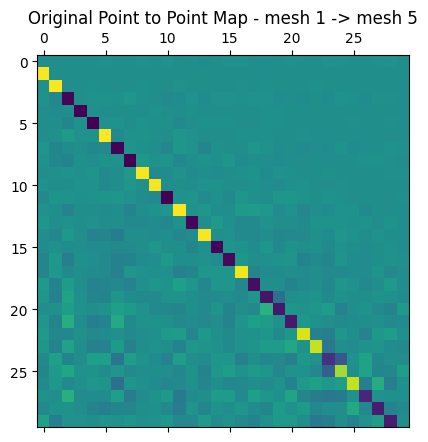

new map shape: (30, 30)


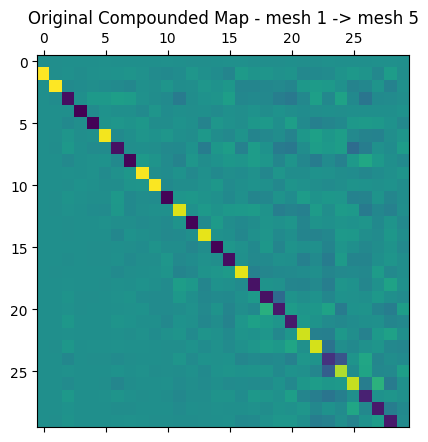

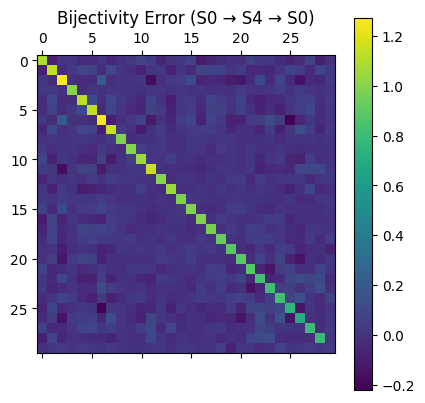

Bijectivity / Consistency error: 0.352801


In [46]:
ind1 = 0
ind2 = 4

print(f"maps_dict = {len(maps_dict)}")
print(f"optimised_dict = {len(compound_dict)}")

double_fm_display(ind1, ind2, maps_dict, compound_dict)

# TEST BIJECTIVITY
# Extract forward and backward maps
map_ij = maps_dict[(ind1, ind2)]  # T_ij: Si → Sj
map_ji = maps_dict[(ind2, ind1)]  # T_ji: Sj → Si

# Compose: T_ji @ T_ij  (map from Si → Si)
compound = map_ji @ map_ij
plt.matshow(compound)
plt.title(f"Bijectivity Error (S{ind1} → S{ind2} → S{ind1})")
plt.colorbar()
plt.show()

# Identity for shape Si
identity = np.eye(compound.shape[0])

# Bijectivity / consistency error
error = np.linalg.norm(identity - compound) / np.linalg.norm(identity)
print(f"Bijectivity / Consistency error: {error:.6f}")

In [ ]:
from FMN_Edited import FMN_Edited
fmn_model_new = FMN_Edited(mesh_list, compound_dict.copy())

#load
with open("../../true_compound_maps_10_w_decay.pkl", "rb") as f:
    fmn_model_new.maps = p.load(f)
    #new_maps_dict = p.load(f)

Setting 90 edges on 10 nodes.


new map shape: (78, 78)


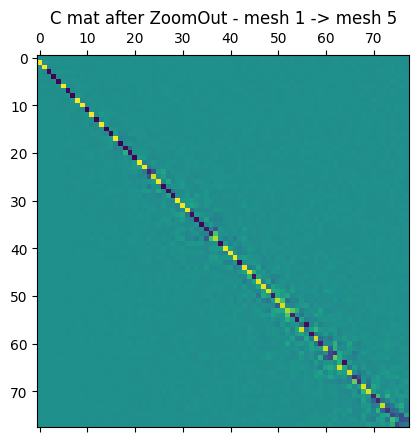

NameError: name 'double_plot' is not defined

In [35]:
ind_1 = 0
ind_2 = 4

mesh1, mesh2 = mesh_list[ind_1], mesh_list[ind_2]
new_maps_dict = fmn_model_new.maps
new_fm_12 = new_maps_dict[(ind_1, ind_2)]

fm_display(ind_1, ind_2, new_maps_dict, meshes=mesh_list, mesh_display=True)
